# Final Project

**Due date: 06-December-2024**

## Requirements

For your final project you will develop a data narrative with a dataset of your choosing. Your data can come from any source. You do not have to comprehensively explore your data. Pick an interesting aspect or two from which to build your narrative.

- At least **three** visualizations. Visualizations can be simple bar charts that total data categories or rich exploratory figures. (*Tables also count as visualizations but you must have at least two charts.*) 
- All of the code should be recorded in your narrative. That is, I should be able to run your notebook code start to finish re-producing each of your outputs without error.
- At least **two** but no more than **three** paragraphs walking the reader through your analysis.
- Charts should exhibit your command of `ggplot2/dplyr/forcats/tidyr` with: 
  - sensibly sorted categories, 
  - interpretable labels/axis titles, 
  - useful annotations (when applicable), 
  - adjustments to default chart aesthetics, 
  - appropriate markings (e.g. `geoms`) and encodings.

In [66]:
library('tidyverse')
options(repr.plot.width = 6, repr.plot.height = 4, repr.plot.res = 250)

In [2]:
auditions = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/auditions.csv')
eliminations = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/eliminations.csv')
finalists = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/finalists.csv')
ratings = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/ratings.csv')
seasons = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/seasons.csv')
songs = read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2024/2024-07-23/songs.csv')

Rows: 142 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): audition_city, audition_venue, episodes, episode_air_date, callbac...
dbl  (2): season, tickets_to_hollywood
date (4): audition_date_start, audition_date_end, callback_date_start, callb...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 456 Columns: 46
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (44): place, gender, contestant, top_36, top_36_2, top_36_3, top_36_4, t...
dbl  (1): season
lgl  (1): comeback

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 190 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): Contestant, B

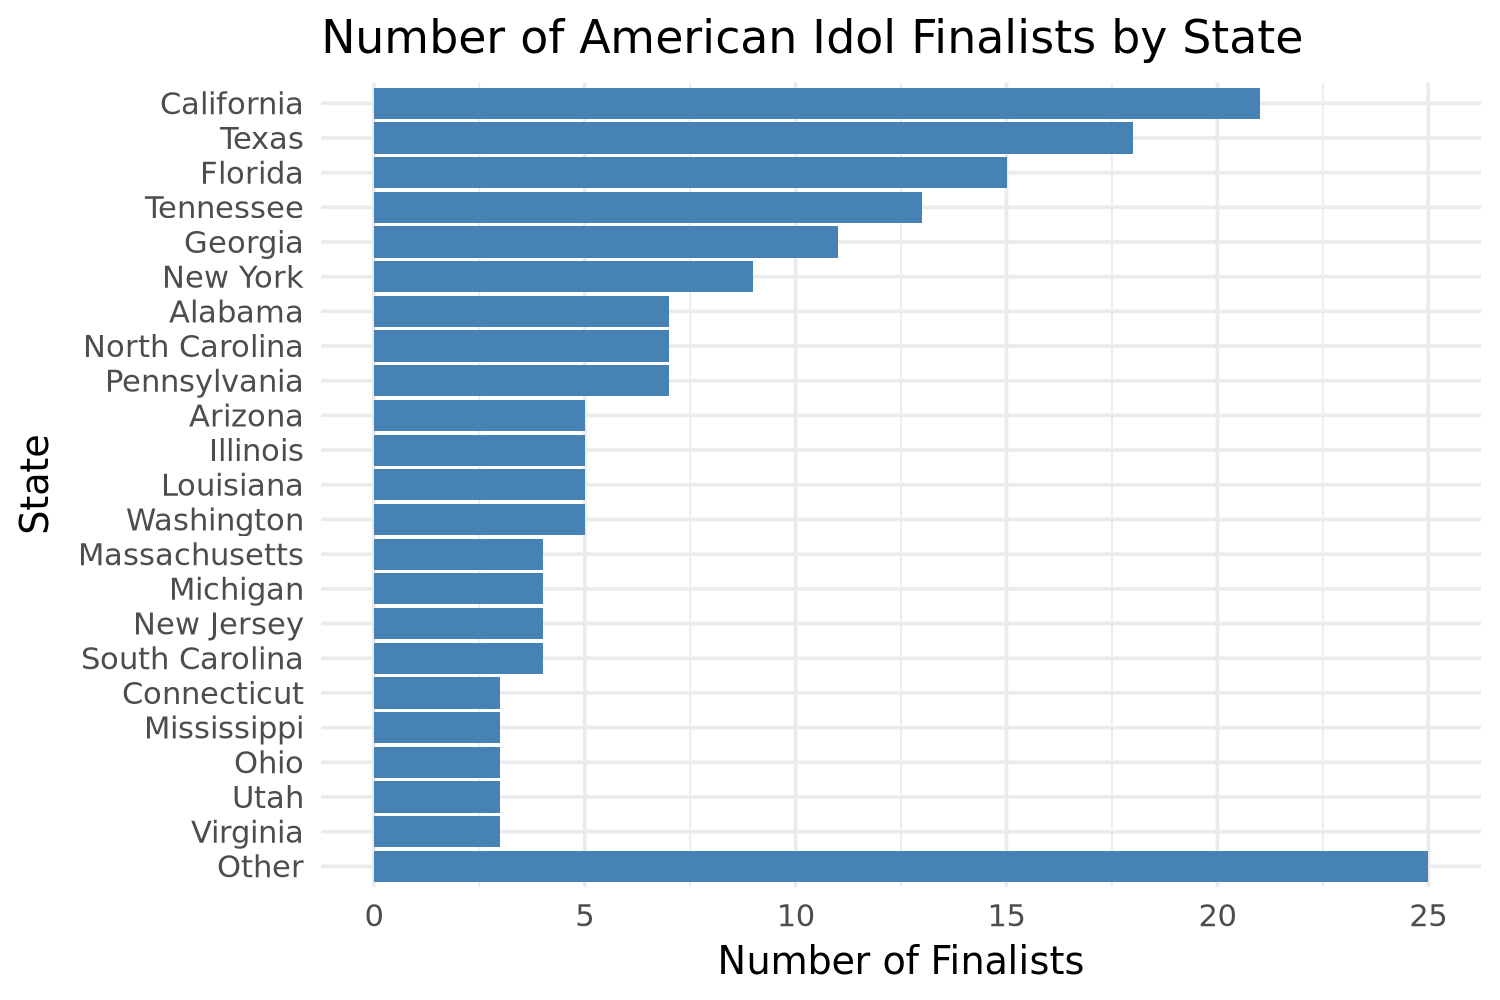

In [67]:
names(finalists) = str_to_lower(names(finalists))

# home_state data prep
finalists_2 = finalists |>
    mutate(hometown_new = ifelse(hometown == "NA" | is.na(hometown), birthplace, hometown)) |>
    separate(hometown_new, c("hometown_city", "home_state"), sep = ",") |>
    filter(!is.na(home_state)) |>
    mutate(
        home_state = fct_infreq(home_state) |>
        fct_lump(n = 20) |>
        fct_relevel('Other', after = Inf) |>
        fct_rev())

ggplot(finalists_2, aes(y = home_state)) +
    geom_bar(fill = "steelblue") +
    labs(title = "Number of American Idol Finalists by State", 
         x = "Number of Finalists", 
         y = "State") +
    theme_minimal()

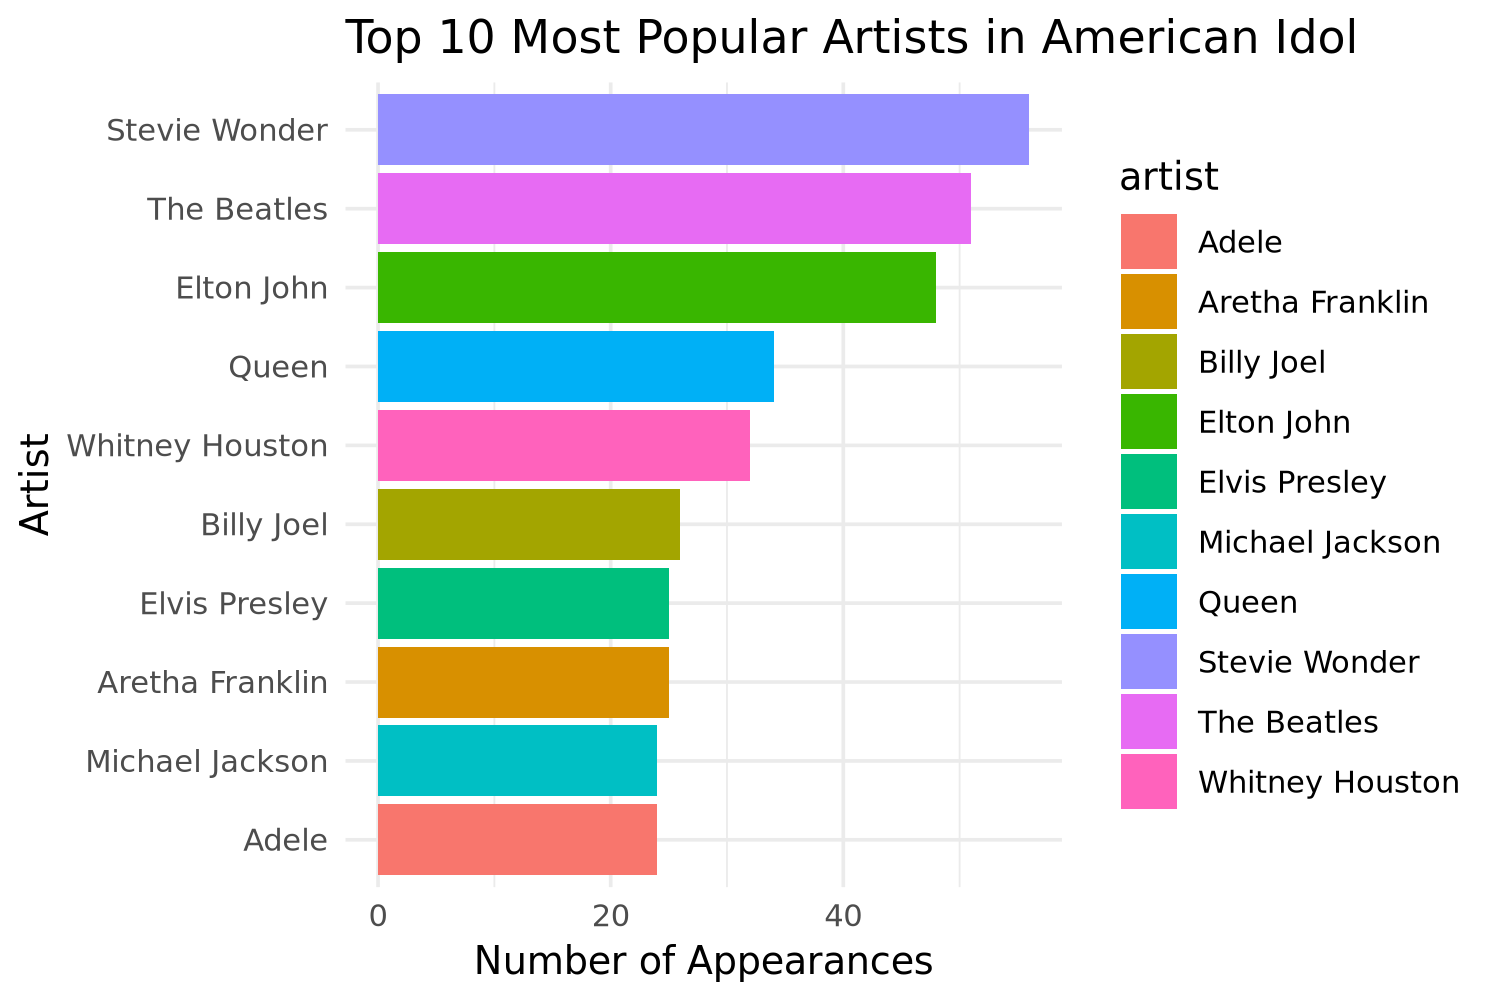

In [64]:
top_artists_all_seasons <- songs %>%
  count(artist, sort = TRUE) %>%
  slice_max(order_by = n, n = 10)

ggplot(top_artists_all_seasons, aes(x = reorder(artist, n), y = n, fill = artist)) +
  geom_bar(stat = 'identity') +
  coord_flip() +
  theme_minimal() +
  labs(title = "Top 10 Most Popular Artists in American Idol", x = "Artist", y = "Number of Appearances")

For these first two graphs, I wanted to find out which states in the United States had the most finalists, and I also wanted to find out which artists' songs were sang most. For the first graph, I first had removed columns of data that was unabailable. Next I made a home state column by separating hometown. I then used `geom_bar` to create the visualization. For the second bar chart, I followed a simialr process. I didn't have to create a new column this time, but I used the `slice` function instead of `fct_lump` since I didn't have to mutate as much. 

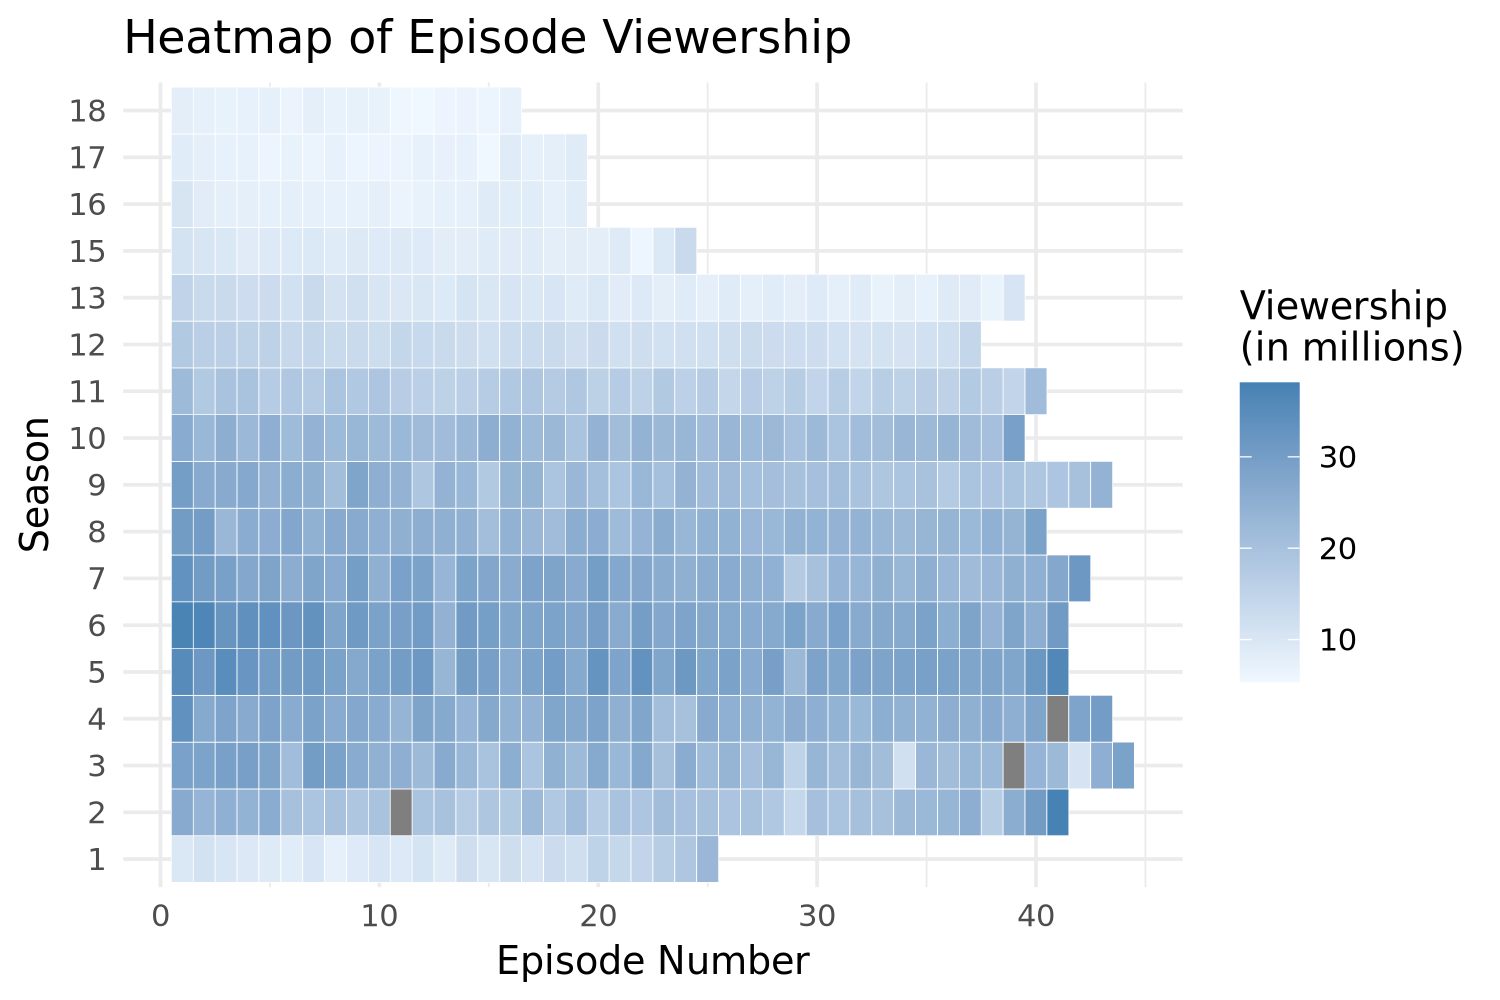

In [65]:
ggplot(plotdf, aes(x = show_number, y = factor(season), fill = viewers_in_millions)) +
    geom_tile(color = "white") +
    scale_fill_gradient(low = "aliceblue", high = "steelblue", name = "Viewership\n(in millions)") +
    labs(
        title = "Heatmap of Episode Viewership",
        x = "Episode Number",
        y = "Season"
        ) +
  theme_minimal()

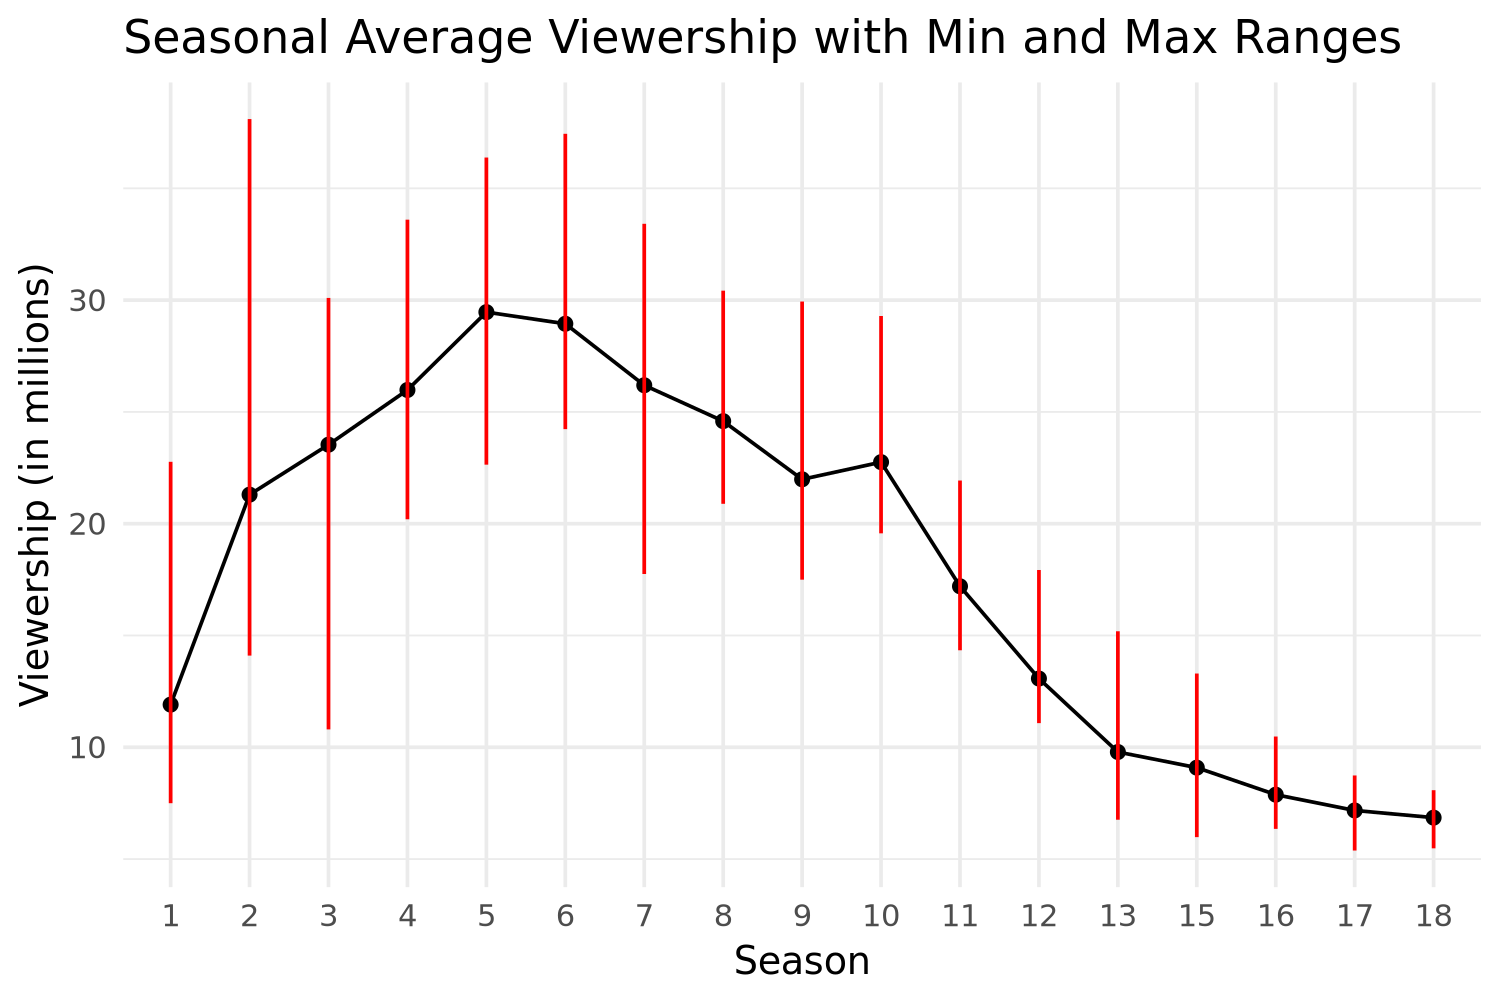

In [51]:
ratings_2 <- ratings |>
  group_by(season) |>
  summarize(
    mean_viewership = mean(viewers_in_millions, na.rm = TRUE),
    min_viewership = min(viewers_in_millions, na.rm = TRUE),
    max_viewership = max(viewers_in_millions, na.rm = TRUE))

ggplot(ratings_2, aes(x = factor(season), y = mean_viewership)) +
    geom_line(group = 1) + 
    geom_point() +
    geom_segment(
    aes(x = factor(season), xend = factor(season),
        y = min_viewership, yend = max_viewership),
    color = "red", size = 0.5) + # Min & max range for each season
labs(
    title = "Seasonal Average Viewership with Min and Max Ranges",
    x = "Season",
    y = "Viewership (in millions)") +
  theme_minimal()

For these next two visualizations, I initally wanted to see which season had the most views and when. I created a heat mat to accomplish this. I accomplished this by using `geom_tile`. I saw season 6 had the darkest tiles, and tiles tended to be darker at the beginning of the season, but I wanted to better visualize how many views were in each season. I used `geom_line` and `geom_point` to create a line of mean season viewership. I then also wanted to visualze the minimum and maximum values for each season to see if h

## Notes

*This project should not take you longer than the time to complete two of our assignments. It is meant to demonstrate that you can build an analysis using `R` and the `Tidyverse` from scratch. Focus your analysis on a small number of data features that you find interesting.*

*Remember all the ways of visualizing distributions (ECDFs, histograms, jitter-ed scatter plots, etc.). These will come in very handy!* 